# Spike Analysis

In [32]:
# Mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.signal import argrelextrema

## Load Data

In [33]:
# Load the .mat file
mat_contents = loadmat('./data/data.mat')

# Extract data and sampling interval
data = mat_contents['data'].squeeze()
sampling_interval = mat_contents['samplingInterval'][0][0]

sfreq = 1 / (sampling_interval * 1e-3) # sampling frequency
time = np.linspace(0, len(data) / sfreq, len(data)) # time axis
RP = 1e-3 # refractory period (1 ms)

## Spike Detection

In [34]:
def PTSD(data, th, PLP, overshoot, RP, sfreq):
    """
    Spike detection using the Precision Timing Spike Detection (PTSD) algorithm.

    Args:
        data (numpy array):The 1D input signal.
        th (float): Differential threshold.
        PLP (float): Peak lifetime period in seconds.
        overshoot (float): Additional window size to search for a local minimum in seconds.
        RP (float): Refractory period.
        sfreq (float): Sampling frequency in Hz.

    Returns:
        spike_train: A 1D numpy array containing spike positions.
    """
    # Find relative maxima
    relative_maxima = argrelextrema(data, np.greater)[0]
    spike_positions = []  # Initialize list to store spike positions

    # Convert to samples
    PLP = int(PLP * sfreq)
    overshoot = int(overshoot * sfreq)
    RP = int(RP * sfreq)

    for pos_max in relative_maxima:
        ampl_max = data[pos_max]
        # Search for a local minimum within PLP
        if pos_max + PLP < len(data):
            pos = np.arange(pos_max, min(pos_max + PLP + 1, len(data))) # Include endpoint
            rm = argrelextrema(data[pos], np.less)[0]
            if len(rm) > 0:  # Local minimum found within PLP
                ampl_min = data[pos[rm[0]]]
            else:  # No local minimum in PLP, extend the search
                pos = np.arange(pos_max, min(pos_max + PLP + overshoot + 1, len(data))) # Include endpoint
                rm = argrelextrema(data[pos], np.less)[0]
                if len(rm) > 0:
                    ampl_min = data[pos[rm[0]]]
                else:
                    continue # No local minimum found even after overshoot

            # Check threshold and refractory period
            if abs(ampl_max - ampl_min) >= th:
              if not spike_positions or abs(spike_positions[-1] - pos_max) > RP:
                  spike_positions.append(pos_max)
    return np.array(spike_positions)

# Precision timing spike detection (PTSD)
PLP = 2e-3 # peak lifetime period
th = np.mean(data) + 8*np.std(data)
overshoot = 1e-3
spike_train_ptsd = PTSD(data, th, PLP, overshoot, RP, sfreq)

## Spike train visualization
A spike train plot visually represents the timing of spikes in a single neuron or trial over time. Each spike is marked by a vertical line at the precise time it occurred. This type of plot provides a clear view of the firing patterns and temporal dynamics of neuronal activity, making it a useful tool for analyzing the timing and frequency of spikes in response to stimuli or during specific behavioral states.

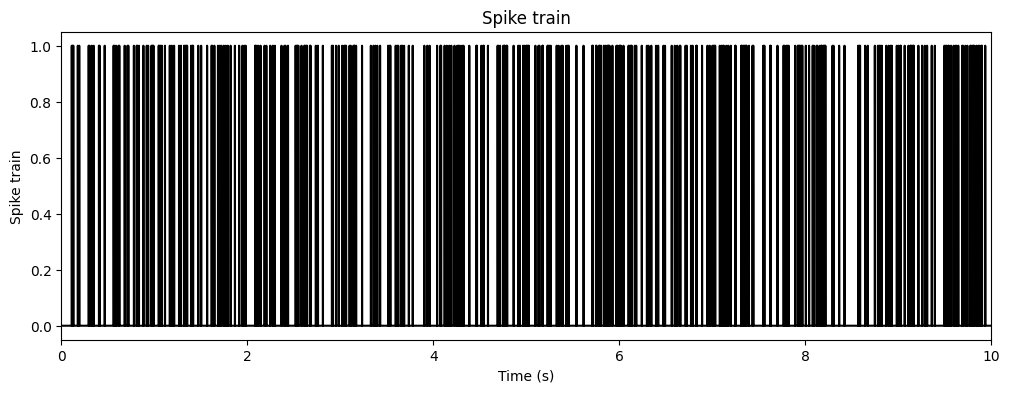

In [35]:
def plot_spike_train(spike_train, fs, ax):
  """
  Plot a spike train.

  Args:
    spike_train (numpy array): Spike times in samples.
    fs (float): Sampling frequency in Hz.
    ax (matplotlib.axes.Axes): Axes object to plot the results.
  """
  # Create a spike train plot array
  spike_train_plot = np.zeros(len(data))

  # Set the positions of the spikes to 1 in the spike train plot array
  spike_train_plot[spike_train] = 1

  # Plot spike train
  ax.plot(np.arange(len(data)) / fs, spike_train_plot, color='k')
  ax.set_xlim([0, len(data) / fs])
  ax.set_xlabel('Time (s)')
  ax.set_ylabel('Spike train')
  ax.set_title('Spike train')

# Plot spike train
plt.figure(figsize=(12, 4))
plot_spike_train(spike_train_ptsd, sfreq, plt.gca())
plt.show()


## Mean firing rate (MFR)
The mean firing rate (MFR) is the average number of spikes per unit time, typically measured in spikes per second (Hz). It provides an overall measure of a neuron's activity level over a given period.

For the entire network:
$$ MFR = \frac{\sum_1^M{N_j}}{T} $$
*   $N_{j}$ is the number of spikes in the $T$ window for the $j^{th}$ electrode.
*   $M$ is the number of recording channels of the network.

In [36]:
def MFR(spike_train, sfreq, data_size):
    """
    Mean firing rate (MFR) from spike times.

    Args:
      spike_train (numpy array): Spike times in samples.
      sfreq (float): Sampling frequency in Hz.

    Returns:
      A tuple containing:
        - mfr: The mean firing rate in Hz.
    """
    # MFR implementation
    T = data_size / sfreq
    mfr = len(spike_train) / T
    return mfr

# Compute MFR
mfr = MFR(spike_train_ptsd, sfreq, len(data))
print(f"Mean firing rate: {mfr:.2f} Hz")

Mean firing rate: 34.40 Hz


## Spike count
The spike count is the total number of spikes occurring within a given time bin
$[a, b]$. By counting spikes in successive time bins, we obtain a histogram representing spike occurrences over time.

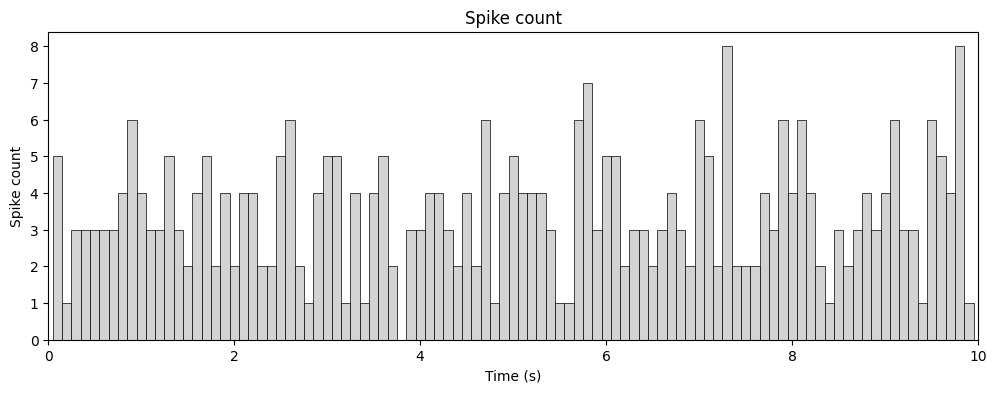

In [37]:
def spike_count(spike_train, sfreq, bin_size, data_size):
    """
    Spike count histogram.

    Args:
      spike_train (numpy array): Spike times in samples.
      sfreq (float): Sampling frequency in Hz.
      bin_size (float): The size of each bin in seconds.

    Returns:
      A tuple containing:
        - bin_edges: A 1D numpy array of bin edges.
        - spike_counts: A 1D numpy array of spike counts per bin.
    """
    # Spike count implementation
    wdw = int(bin_size * sfreq)
    bin_edges = np.arange(0, data_size+1, wdw)
    spike_counts = np.zeros(len(bin_edges) - 1)
    for i in range(len(bin_edges) - 1):
        spike_counts[i] = np.sum((spike_train >= bin_edges[i]) & (spike_train < bin_edges[i + 1]))
    return bin_edges, spike_counts

# Spike count
bin_size = 100e-3  # Example bin size of 100ms

# Plot spike count
plt.figure(figsize=(12, 4))
bin_edges, spike_counts = spike_count(spike_train_ptsd, sfreq, bin_size, len(data))
plt.bar(bin_edges[:-1] / sfreq, spike_counts, width=bin_size, color='lightgray', edgecolor='black', linewidth=0.5)
plt.xlabel('Time (s)')
plt.xlim(0, 10) # set x axis limit
plt.ylabel('Spike count')
plt.title('Spike count')
plt.show()


## Instantaneous firing rate (IFR)
The instantaneous firing rate (IFR) is computed by normalizing the spike count histogram by the bin size. This provides a time-resolved estimate of neuronal activity and can be smoothed for better visualization:

$$ r(t) = \frac{N_{ab} (t)}{\Delta t}$$

* $[t_a, t_b]$ is the bin size.
* $N_{ab}$ is the number of spikes within the interval $[t_a, t_b]$.

By choosing shorter bins, we achieve higher temporal resolution, capturing rapid fluctuations in firing activity.\
Smoothed IFR estimates can be obtained using convolution with a Gaussian or other smoothing techniques.

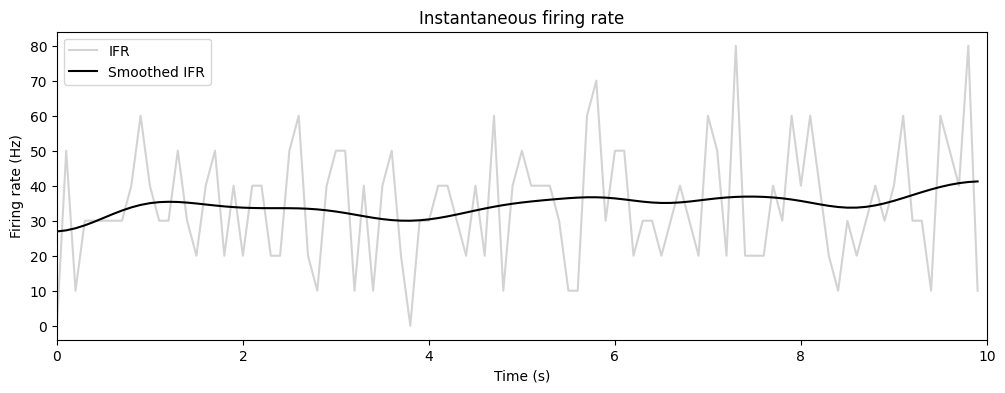

In [38]:
from scipy.ndimage import gaussian_filter1d

def IFR(spike_train, sfreq, bin_size, data_size):
    """
    Instantaneous firing rate (IFR) from spike times.

    Args:
      spike_train (numpy array): Spike times in samples.
      sfreq (float): Sampling frequency in Hz.
      bin_size (float): The size of each bin in seconds.
      data_size (int): The total number of samples in the recording.

    Returns:
      A tuple containing:
        - bin_edges: A 1D numpy array of bin edges.
        - ifr: A 1D numpy array of IFR values per bin.
        - ifr_smoothed: A 1D numpy array of smoothed IFR values.
    """
    # IFR implementation
    wdw = int(bin_size * sfreq)
    bin_edges = np.arange(0, data_size+1, wdw)
    ifr = np.zeros(len(bin_edges) - 1)
    for i in range(len(bin_edges) - 1):
        ifr[i] = np.sum((spike_train >= bin_edges[i]) & (spike_train < bin_edges[i + 1])) / bin_size
    ifr_smoothed = gaussian_filter1d(ifr, sigma=5)

    return bin_edges, ifr, ifr_smoothed

# Compute IFR
bin_size = 100e-3  # Example bin size of 100ms

# Plot IFR
plt.figure(figsize=(12, 4))
bin_edges, ifr, ifr_smoothed = IFR(spike_train_ptsd, sfreq, bin_size, len(data))
plt.plot(bin_edges[:-1] / sfreq, ifr, color='lightgray', label='IFR')
plt.plot(bin_edges[:-1] / sfreq, ifr_smoothed, color='black', label='Smoothed IFR')
plt.xlabel('Time (s)')
plt.xlim(0, 10) # set x axis limit
plt.ylabel('Firing rate (Hz)')
plt.title('Instantaneous firing rate')
plt.legend()
plt.show()

## Inter-spike interval histogram (ISIH)
The inter-spike interval (ISI) represents the time difference between two consecutive spikes. Analyzing the distribution of ISIs helps understand the temporal firing patterns of neurons.

The inter-spike interval histogram (ISIH) represents the statistical distribution of ISIs, showing the probability that a spike occurs at a certain time after a previous spike.\
The result can be expressed either as a percentage value (probability) or as spikes per bin.

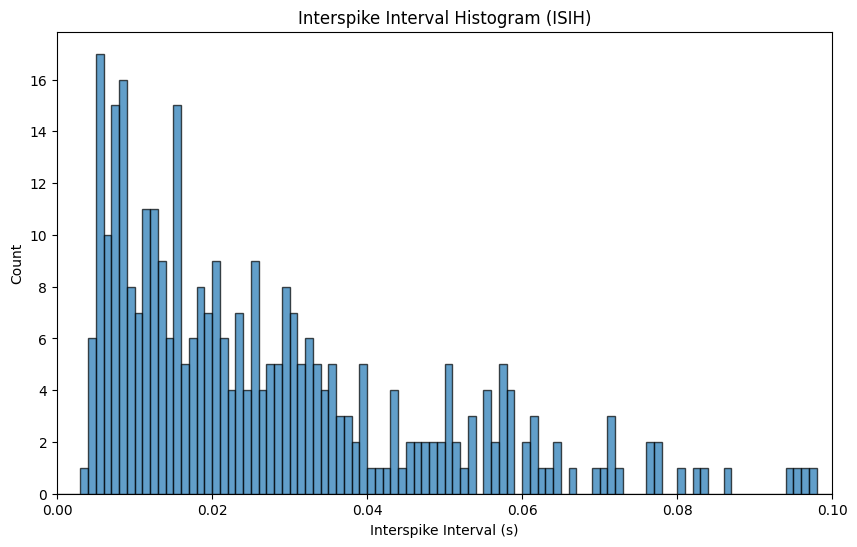

In [39]:
def ISIH(spike_train, sfreq, bin_size, max_isi, normalize=False):
    """
    Computes the Inter Spike Interval Histogram (ISIH).

    Args:
      spike_train (numpy array): Spike times in samples.
      sfreq (float): Sampling frequency in Hz.
      bin_size (float): The size of each bin in seconds.
      max_isi (float): Maximum ISI to consider (in seconds), optional.
      normalize (bool): If True, returns the histogram as a probability distribution.

    Returns:
      A tuple containing:
        - bin_edges: A 1D numpy array of bin edges.
        - isih: A 1D numpy array of ISI counts (or probabilities if normalized).
    """
    # ISIH implementation
    wdw = int(bin_size * sfreq)
    max_isi_samples = int(max_isi * sfreq)
    bin_edges = np.arange(0, max_isi_samples + wdw, wdw)  # Ensure last bin edge is included
    isih, _ = np.histogram(np.diff(spike_train), bins=bin_edges)

    if normalize:
        isih = isih / np.sum(isih)

    return bin_edges[:-1] / sfreq, isih  # Return bin edges in seconds

bin_size = 0.001  # 1ms bin size
max_isi = 0.1      # 100ms max ISI
normalize = False

bin_edges, isih = ISIH(spike_train_ptsd, sfreq, bin_size, max_isi, normalize)

# Plotting the ISIH
plt.figure(figsize=(10, 6))
plt.bar(bin_edges, isih, width=bin_size, align='edge', edgecolor='black', alpha=0.7)
plt.xlabel('Interspike Interval (s)')
plt.ylabel('Count')
plt.title('Interspike Interval Histogram (ISIH)')
plt.xlim(0, max_isi)
plt.show()


## Raster Plot

In [40]:
# Load a data with 16 channels
data_raster = loadmat('./data/data_16chs.mat')['data']
sfreq = 25e3
n_chs = data_raster.shape[0]

# Spike detection
PLP = 2e-3 # peak lifetime period
overshoot = 1e-3

spike_train_raster = np.zeros_like(data_raster, dtype=int)
for ch in range(n_chs):
    th = np.mean(data_raster[ch]) + 5*np.std(data_raster[ch])
    spike_train = PTSD(data_raster[ch], th, PLP, overshoot, RP, sfreq)
    spike_train_raster[ch, spike_train] = 1

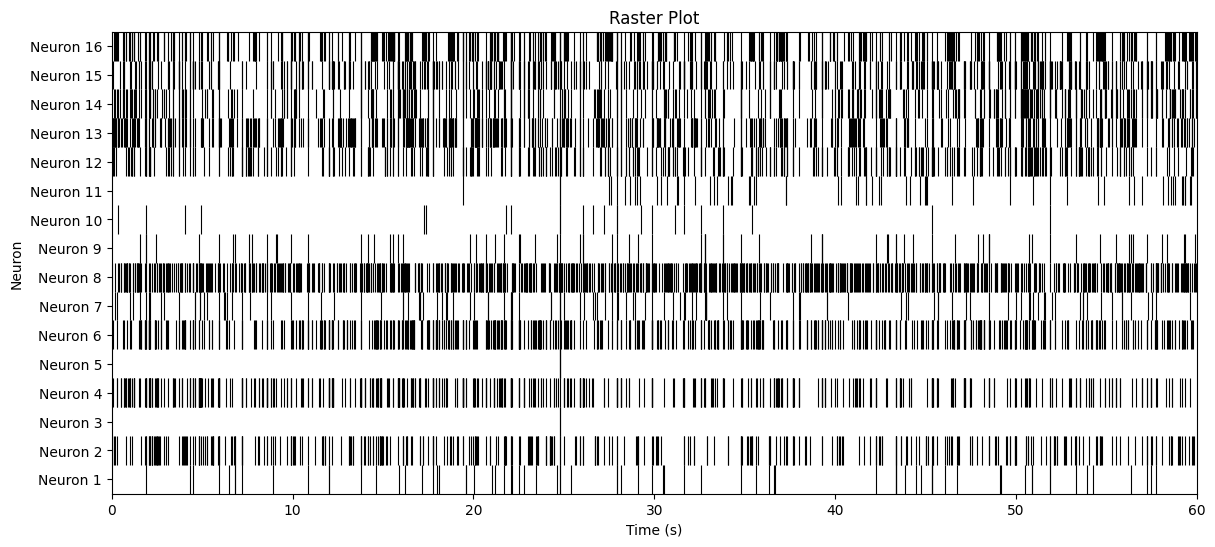

In [42]:
def plot_raster(spike_trains, sfreq, ax):
    """
    Plots a raster plot of spike trains.

    Args:
      spike_trains (numpy array): A 2D numpy array where each row represents a spike train.
                                  Spike times should be represented as indices (samples).
      sfreq (float): Sampling frequency in Hz.
      ax (matplotlib.axes._axes.Axes): The matplotlib axes object to plot on.
    """
    n_trains = spike_trains.shape[0]
    duration = spike_trains.shape[1] / sfreq  # Duration of recording in seconds

    for i in range(n_trains):
        spike_times = np.where(spike_trains[i] == 1)[0] / sfreq  # Spike times in seconds
        ax.vlines(spike_times, i + 0.5, i + 1.5, color='k', linewidth=0.8)

    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Neuron')
    ax.set_yticks(np.arange(1, n_trains + 1))
    ax.set_yticklabels([f'Neuron {i+1}' for i in range(n_trains)])
    ax.set_xlim(0, duration)
    ax.set_ylim(0.5, n_trains + 0.5)
    ax.set_title('Raster Plot')

fig, ax = plt.subplots(figsize=(14, 6))
plot_raster(spike_train_raster, sfreq, ax)
plt.show()